## Test on lookahead gd: Vary alpha, continuous update, and linear interpolation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
from lookahead import lookahead_sgd, lookahead_adaptive_alpha, lookahead_continuous_sync, lookahead_tanh
from optimizers import sgd_baseline

In [3]:
# ── Loss & gradient ───────────────────────────────────────────────────────────
def sphere_fn(theta):
    x, y = theta
    return x**2 + y**2

def sphere_gd(theta):
    x, y = theta
    return np.array([2*x, 2*y])   # FIX: must return a vector, not a scalar


# ── Rosenbrock  f(x,y) = (1-x)² + 100(y-x²)²  —  global min = 0 at (1, 1) ──
def rosenbrock_fn(theta):
    x, y = theta
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_gd(theta):
    x, y = theta
    dfdx = -2 * (1 - x) - 400 * x * (y - x**2)
    dfdy =  200 * (y - x**2)
    g = np.array([dfdx, dfdy])
    return np.clip(g, -10.0, 10.0)   # clip to prevent gradient explosion


def rastrigin_fn(theta):
    A = 2*10
    return A + sum([(x**2 - A * np.cos(2 * math.pi * x)) for x in theta])

def rastrigin_gd(theta):
    A = 2*10
    return np.array([2*x - 2*math.pi*A * np.sin(2 * math.pi * x) for x in theta])



In [4]:
# ── Plot ──────────────────────────────────────────────────────────────────────
def draw_path(ax, trajectory, color, label):
    """Draw a trajectory with directional arrows on ax."""
    pts = np.array(trajectory)          # shape (N, 2)
    tx, ty = pts[:, 0], pts[:, 1]

    ax.plot(tx, ty, color=color, linewidth=1.5, alpha=0.8, label=label)
    ax.scatter(tx[0],  ty[0],  s=100, color="lime",  zorder=5)
    ax.scatter(tx[-1], ty[-1], s=100, color=color,   zorder=5, marker="*")

    step = max(1, len(tx) // 15)
    for i in range(0, len(tx) - step, step):
        ax.annotate("",
            xy=(tx[i+step], ty[i+step]),
            xytext=(tx[i], ty[i]),
            arrowprops=dict(arrowstyle="->", color=color, lw=1.0),
        )
def plot_trajectories(fn, master_trajectory, gd_trajectory,minimum, r=2.0):
    xs = np.linspace(-r, r, 400)
    ys = np.linspace(-r, r * 1.5, 400)   # taller range to capture the valley
    Z  = np.array([[fn(np.array([xi, yj])) for xi in xs] for yj in ys])

    fig, ax = plt.subplots(figsize=(8, 7))
    cp = ax.contourf(xs, ys, np.log1p(Z), levels=60, cmap="viridis")  # log scale so the valley is visible
    plt.colorbar(cp, ax=ax, label="log(1 + Loss)")

    draw_path(ax, gd_trajectory,     color="tomato", label="Plain GD")
    draw_path(ax, master_trajectory, color="white",  label="EASGD master")

    ax.scatter([], [], s=100, color="lime", label="Start (both)")
    ax.scatter(minimum[0], minimum[1], s=200, color="yellow", marker="*", zorder=6, label="Global min")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title("Plain GD vs EASGD Master — Rosenbrock function")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_traj_mult(fn, traj_list, traj_names, gd_trajectory,minimum, r=2.0):
    # traj names is a list of strings for the legend
    xs = np.linspace(-r, r, 400)
    ys = np.linspace(-r, r * 1.5, 400)   # taller range to capture the valley
    Z  = np.array([[fn(np.array([xi, yj])) for xi in xs] for yj in ys])

    fig, ax = plt.subplots(figsize=(8, 7))
    cp = ax.contourf(xs, ys, np.log1p(Z), levels=60, cmap="viridis")  # log scale so the valley is visible
    plt.colorbar(cp, ax=ax, label="log(1 + Loss)")

    draw_path(ax, gd_trajectory,     color="white", label="Plain GD")
    for i, trajectory in enumerate(traj_list):
        draw_path(ax, trajectory, color=plt.cm.hot(i / len(traj_list)), label=traj_names[i])

    ax.scatter([], [], s=100, color="lime", label="Start (both)")
    ax.scatter(minimum[0], minimum[1], s=200, color="yellow", marker="*", zorder=6, label="Global min")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title("Plain GD vs EASGD Master — Rosenbrock function")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_traj_mult_panel(fn, traj_list, traj_names, gd_trajectory,minimum, r=2.0):
    # traj names is a list of strings for the legend
    # now multiple subfigs, in each traj vs gd
    xs = np.linspace(-r, r, 400)
    ys = np.linspace(-r, r * 1.5, 400)   # taller range to capture the valley
    Z  = np.array([[fn(np.array([xi, yj])) for xi in xs] for yj in ys])

    n = len(traj_list)
    fig, axs = plt.subplots(1, n, figsize=(5*n, 5))
    for i, trajectory in enumerate(traj_list):  
        ax = axs[i]
        cp = ax.contourf(xs, ys, np.log1p(Z), levels=60, cmap="viridis")  # log scale so the valley is visible
        draw_path(ax, gd_trajectory,     color="black", label="Plain GD")
        draw_path(ax, trajectory, color="red", label=traj_names[i])
        ax.scatter([], [], s=100, color="lime", label="Start (both)")
        ax.scatter(minimum[0], minimum[1], s=200, color="yellow", marker="*", zorder=6, label="Global min")
        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.set_title(f"Plain GD vs {traj_names[i]} — Rosenbrock function")
        ax.legend()
    plt.tight_layout()
    plt.show()

SGD baseline completed in 0.08 seconds.
Lookahead completed in 0.06 seconds.
Adaptive Lookahead completed in 0.05 seconds.
Continuous sync completed in 0.07 seconds.
Tanh Lookahead completed in 0.05 seconds.


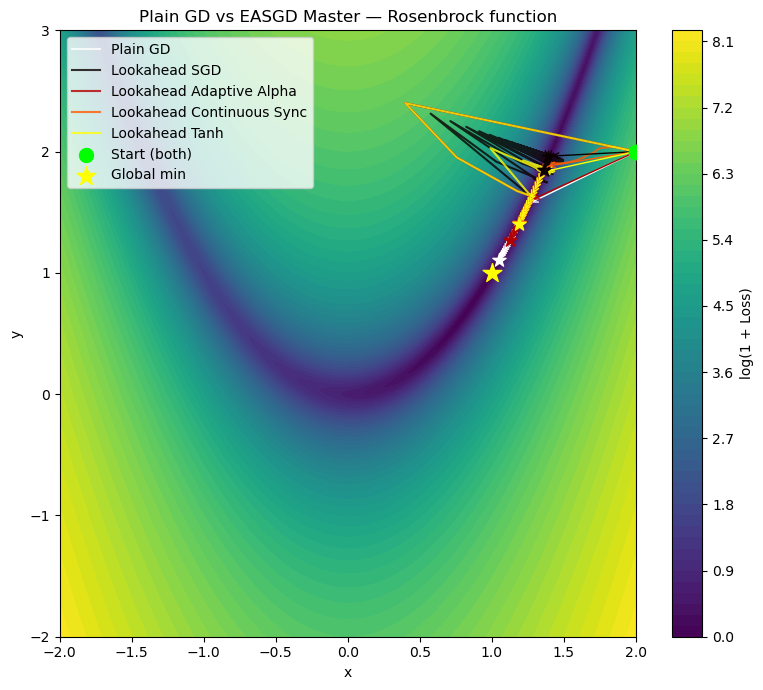

In [9]:
# gd's return dict, need to acces trajectory
theta_init = [2, 2]
lr_gd = 0.001
lr_lk = 0.1
alpha = 0.1
baseline_gd_traj = sgd_baseline(func=rosenbrock_fn, theta_init=theta_init, lr=lr_gd, n_steps=5000)["traj"]
lookahead_baseline_traj = lookahead_sgd(func=rosenbrock_fn, theta_init=theta_init, lr=lr_gd, k=20, alpha=alpha, n_steps=5000)["traj"]
lookahead_adaptive_alpha_traj = lookahead_adaptive_alpha(func=rosenbrock_fn, theta_init=theta_init, lr=lr_gd, k=20, n_steps=5000)["traj"]
lookahead_continuous_sync_traj = lookahead_continuous_sync(func=rosenbrock_fn, theta_init=theta_init, lr=lr_gd, alpha=alpha, n_steps=5000)["traj"]
lookahead_tanh_traj = lookahead_tanh(func=rosenbrock_fn, theta_init=theta_init, lr=lr_gd, k=20, n_steps=5000)["traj"]    

traj_list = [lookahead_baseline_traj, lookahead_adaptive_alpha_traj, lookahead_continuous_sync_traj, lookahead_tanh_traj]
traj_names = ["Lookahead SGD", "Lookahead Adaptive Alpha", "Lookahead Continuous Sync", "Lookahead Tanh"]

plot_traj_mult(rosenbrock_fn, traj_list, traj_names, baseline_gd_traj, minimum=(1, 1), r=2.0)

SGD baseline completed in 0.09 seconds.
Lookahead completed in 0.05 seconds.
Adaptive Lookahead completed in 0.04 seconds.
Continuous sync completed in 0.06 seconds.
Tanh Lookahead completed in 0.05 seconds.


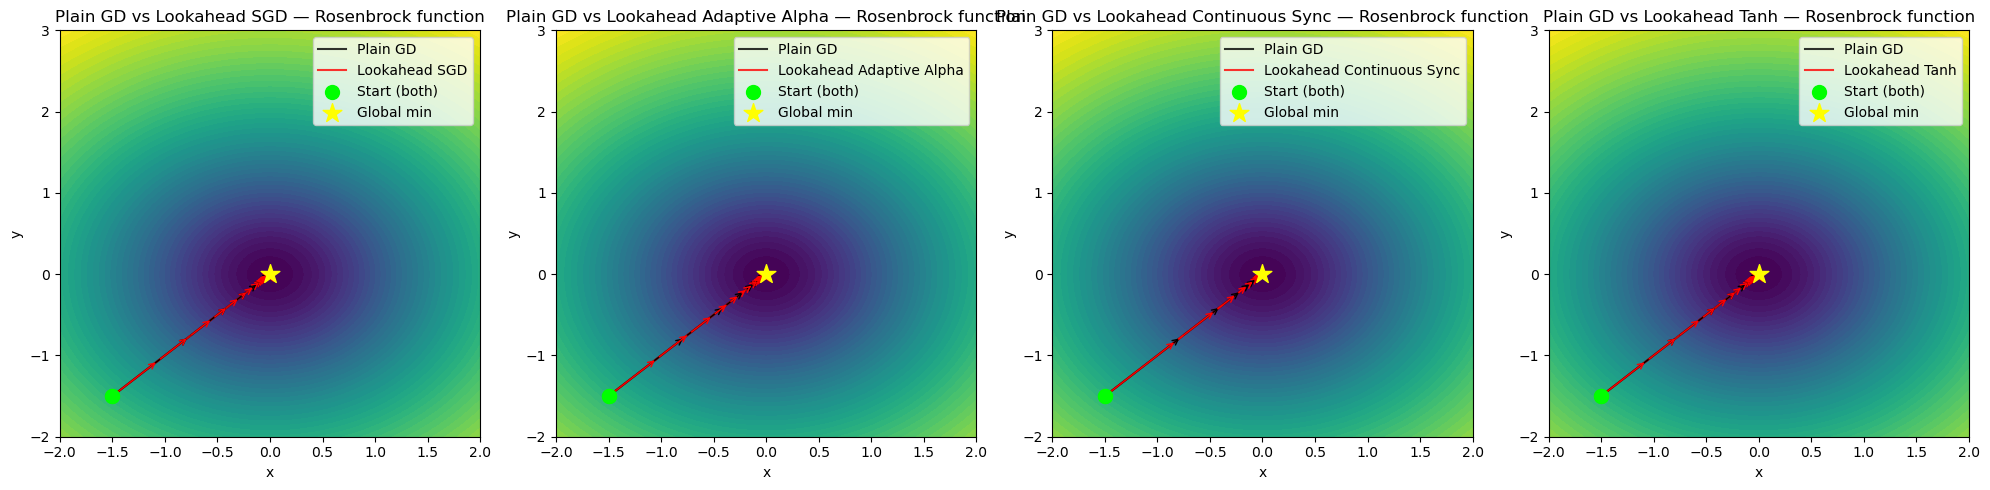

In [10]:
theta_init = [-1.5, -1.5]
lr_gd = 0.001
lr_lk = 0.01
baseline_gd_traj = sgd_baseline(func=sphere_fn, theta_init=theta_init, lr=lr_gd, n_steps=5000)["traj"]
lookahead_baseline_traj = lookahead_sgd(func=sphere_fn, theta_init=theta_init, lr=lr_gd, k=20, alpha=0.5, n_steps=5000)["traj"]
lookahead_adaptive_alpha_traj = lookahead_adaptive_alpha(func=sphere_fn, theta_init=theta_init, lr=lr_gd, k=20, n_steps=5000)["traj"]
lookahead_continuous_sync_traj = lookahead_continuous_sync(func=sphere_fn, theta_init=theta_init, lr=lr_gd, alpha=0.5, n_steps=5000)["traj"]
lookahead_tanh_traj = lookahead_tanh(func=sphere_fn, theta_init=theta_init, lr=lr_gd, k=20, n_steps=5000)["traj"]    

traj_list = [lookahead_baseline_traj, lookahead_adaptive_alpha_traj, lookahead_continuous_sync_traj, lookahead_tanh_traj]
traj_names = ["Lookahead SGD", "Lookahead Adaptive Alpha", "Lookahead Continuous Sync", "Lookahead Tanh"]

plot_traj_mult_panel(sphere_fn, traj_list, traj_names, baseline_gd_traj, minimum=(0, 0), r=2.0)

SGD baseline completed in 0.15 seconds.
Lookahead completed in 0.10 seconds.
Adaptive Lookahead completed in 0.10 seconds.
Continuous sync completed in 0.10 seconds.
Tanh Lookahead completed in 0.11 seconds.


/var/folders/dv/fpf7xq8j6yzfxjs7g9c_bbyc0000gn/T/ipykernel_63712/2626205498.py:72: RuntimeWarning: invalid value encountered in log1p
  cp = ax.contourf(xs, ys, np.log1p(Z), levels=60, cmap="viridis")  # log scale so the valley is visible


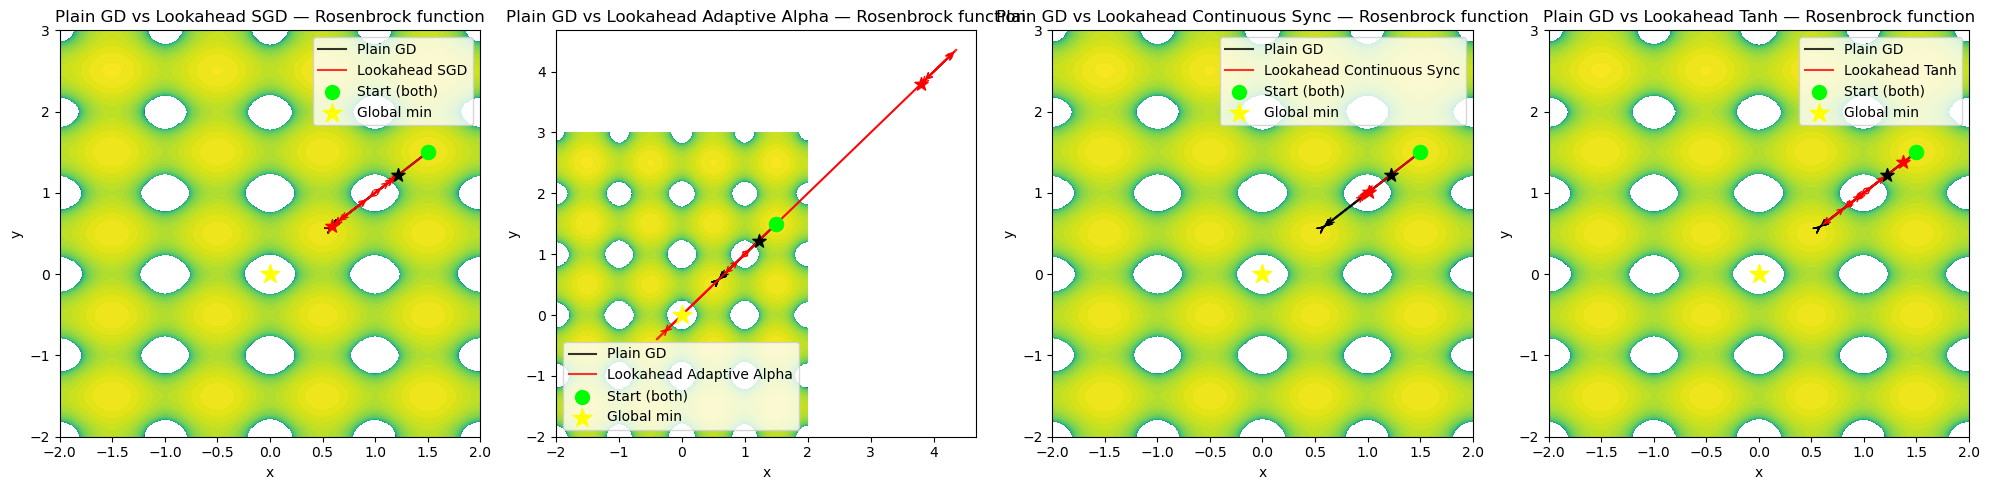

In [14]:
theta_init = [1.5, 1.5]
lr_gd = 0.005
lr_lk = 0.005
baseline_gd_traj = sgd_baseline(func=rastrigin_fn, theta_init=theta_init, lr=lr_gd, n_steps=5000)["traj"]
lookahead_baseline_traj = lookahead_sgd(func=rastrigin_fn, theta_init=theta_init, lr=lr_gd, k=20, alpha=0.1, n_steps=5000)["traj"]
lookahead_adaptive_alpha_traj = lookahead_adaptive_alpha(func=rastrigin_fn, theta_init=theta_init, alpha0=0.1, lr=lr_gd, k=20, n_steps=5000)["traj"]
lookahead_continuous_sync_traj = lookahead_continuous_sync(func=rastrigin_fn, theta_init=theta_init, lr=lr_gd, alpha=0.1, n_steps=5000)["traj"]
lookahead_tanh_traj = lookahead_tanh(func=rastrigin_fn, theta_init=theta_init, lr=lr_gd, k=20, n_steps=5000)["traj"]    

traj_list = [lookahead_baseline_traj, lookahead_adaptive_alpha_traj, lookahead_continuous_sync_traj, lookahead_tanh_traj]
traj_names = ["Lookahead SGD", "Lookahead Adaptive Alpha", "Lookahead Continuous Sync", "Lookahead Tanh"]

plot_traj_mult_panel(rastrigin_fn, traj_list, traj_names, baseline_gd_traj, minimum=(0, 0), r=2.0)